In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from data import prepare_data, make_dataloader
from pathlib import Path
from models import *
import math

In [2]:
MASK_PATH = "../modular_setup_improved/mask_2peaks.parquet" # for training on only those examples with 2 peaks
DATA_PATH = "../modular_setup_improved/synthetic+real_dataset_filtered.parquet"
EMBEDDING_PATH = "../modular_setup_improved/all_fm-rna_embeddings_filtered.pt"
BIN_EDGES_PATH = "bin_edges.npy"
SEED = 42
N_BINS = 50
DEVICE = "cpu"  # change to "cuda" if available

In [3]:
handpicked_cols = ["gc_content", "mfe", "n_local_minima"]
# handpicked_cols = [
#     "mfe", "n_local_minima", "gc_content",
#     "freq_A", "freq_U", "freq_G", "freq_C",
#     "freq_AA", "freq_AU", "freq_AG", "freq_AC",
#     "freq_UA", "freq_UU", "freq_UG", "freq_UC",
#     "freq_GA", "freq_GU", "freq_GG", "freq_GC",
#     "freq_CA", "freq_CU", "freq_CG", "freq_CC"
# ]

In [4]:
if MASK_PATH is not None:
    data_mask = pd.read_parquet(MASK_PATH)
else:
    data_mask = None

data = prepare_data(DATA_PATH, n_bins=N_BINS, random_state=SEED, handpicked_cols=handpicked_cols, bin_edges_path=BIN_EDGES_PATH, data_mask=data_mask)
static_dim = data.train.static_features.shape[1]
output_dim = data.train.targets.shape[1]
bin_centers = (data.bin_edges[:-1] + data.bin_edges[1:]) / 2

In [6]:
data.train.targets[0]

array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.001, 0.002, 0.009, 0.029, 0.073, 0.077, 0.047,
       0.014, 0.017, 0.016, 0.019, 0.023, 0.022, 0.038, 0.063, 0.101,
       0.14 , 0.16 , 0.09 , 0.054, 0.005, 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   ], dtype=float32)

In [5]:
data.test.sequences[0].shape

(40, 4)

In [6]:
data.test.structures[0].shape

(40, 3)

In [7]:
data.test.static_features[0].shape

(3,)

In [8]:
data.test.row_keys

['1756',
 '9016',
 '2482',
 '6026',
 '8384',
 '8365',
 '7133',
 '7641',
 '1013',
 '8948',
 '1437',
 '6492',
 '868',
 '9204',
 '5588',
 '2001',
 '1564',
 '6521',
 '8987',
 '1101',
 '3682',
 '5271',
 '1860',
 '8535',
 '879',
 '2405',
 '9906',
 '1034',
 '9286',
 '1475',
 '9613',
 '1739',
 '8962',
 '1855',
 '7754',
 '5857',
 '10741',
 '9298',
 '5097',
 '804',
 '371',
 '9956',
 '8433',
 '183',
 '5590',
 '968',
 '2662',
 '6446',
 '7448',
 '5253',
 '1670',
 '5542',
 '6254',
 '3306',
 '2000',
 '8766',
 '4880',
 '6024',
 '4276',
 '3822',
 '4687',
 '5974',
 '5083',
 '6918',
 '645',
 '8859',
 '10701',
 '5812',
 '8716',
 '6071',
 '3963',
 '1896',
 '10264',
 '7484',
 '5992',
 '1883',
 '5655',
 '746',
 '6579',
 '9743',
 '6510',
 '5395',
 '8731',
 '6264',
 '1283',
 '1828',
 '5569',
 '778',
 '10211',
 '10335',
 '6440',
 '6410',
 '7685',
 '2028',
 '10313',
 '8615',
 '9752',
 '9221',
 '5318',
 '1819',
 '6475',
 '147',
 '9580',
 '6721',
 '415',
 '2021',
 '1874',
 '4778',
 '9323',
 '863',
 '8993',
 '6505'

In [9]:
data.bin_edges/np.log(10)

array([-3.        , -2.76010949, -2.52021898, -2.28032848, -2.04043797,
       -1.80054746, -1.56065695, -1.32076644, -1.08087594, -0.84098543,
       -0.60109492, -0.36120441, -0.1213139 ,  0.11857661,  0.35846711,
        0.59835762,  0.83824813,  1.07813864,  1.31802915,  1.55791965,
        1.79781016,  2.03770067,  2.27759118,  2.51748169,  2.75737219,
        2.9972627 ,  3.23715321,  3.47704372,  3.71693423,  3.95682474,
        4.19671524,  4.43660575,  4.67649626,  4.91638677,  5.15627728,
        5.39616778,  5.63605829,  5.8759488 ,  6.11583931,  6.35572982,
        6.59562032,  6.83551083,  7.07540134,  7.31529185,  7.55518236,
        7.79507287,  8.03496337,  8.27485388,  8.51474439,  8.7546349 ,
        8.99452541])

In [10]:
data.test.targets.shape

(365, 50)

In [11]:
data.test.row_keys

['1756',
 '9016',
 '2482',
 '6026',
 '8384',
 '8365',
 '7133',
 '7641',
 '1013',
 '8948',
 '1437',
 '6492',
 '868',
 '9204',
 '5588',
 '2001',
 '1564',
 '6521',
 '8987',
 '1101',
 '3682',
 '5271',
 '1860',
 '8535',
 '879',
 '2405',
 '9906',
 '1034',
 '9286',
 '1475',
 '9613',
 '1739',
 '8962',
 '1855',
 '7754',
 '5857',
 '10741',
 '9298',
 '5097',
 '804',
 '371',
 '9956',
 '8433',
 '183',
 '5590',
 '968',
 '2662',
 '6446',
 '7448',
 '5253',
 '1670',
 '5542',
 '6254',
 '3306',
 '2000',
 '8766',
 '4880',
 '6024',
 '4276',
 '3822',
 '4687',
 '5974',
 '5083',
 '6918',
 '645',
 '8859',
 '10701',
 '5812',
 '8716',
 '6071',
 '3963',
 '1896',
 '10264',
 '7484',
 '5992',
 '1883',
 '5655',
 '746',
 '6579',
 '9743',
 '6510',
 '5395',
 '8731',
 '6264',
 '1283',
 '1828',
 '5569',
 '778',
 '10211',
 '10335',
 '6440',
 '6410',
 '7685',
 '2028',
 '10313',
 '8615',
 '9752',
 '9221',
 '5318',
 '1819',
 '6475',
 '147',
 '9580',
 '6721',
 '415',
 '2021',
 '1874',
 '4778',
 '9323',
 '863',
 '8993',
 '6505'

In [27]:
#weights = torch.load('checkpoints/best_bilstm_2peaksonly.pth')
#weights = torch.load('checkpoints/best_bilstm_v2.pth')
#weights = torch.load('checkpoints/best_glm_baseline_v2.pth')

weights = torch.load('checkpoints/best_bilstm_rna_fm_2peaksonly.pth')

In [28]:
#model = DynamicHybridLSTM(hidden_size=64, num_layers=1, static_feature_size=static_dim, output_size=output_dim, mlp_hidden_size=64, bidirectional=False)
#model = GLMBaseline(static_feature_size=static_dim, output_size=output_dim)

model = DynamicEmbeddingHybridLSTM(
            hidden_size=64, 
            num_layers=1, 
            static_feature_size=static_dim,
            output_size=output_dim, 
            embedding_dim=640, # Explicitly configured for RNA-FM dense vectors
            mlp_hidden_size=64, 
            bidirectional=True,
        )

In [29]:
model.load_state_dict(weights)

<All keys matched successfully>

In [30]:
data.test.sequences[0].shape

(40, 4)

In [31]:
data.test.structures[0].shape

(40, 3)

In [32]:
embeddings_dict = torch.load(EMBEDDING_PATH)

if data_mask is not None:
    embeddings_dict_aftermask = {}
    for key in embeddings_dict.keys():
        if data_mask['num_peaks'][int(key)]:
            embeddings_dict_aftermask[key] = embeddings_dict[key]
    embeddings_dict = embeddings_dict_aftermask

In [18]:
embeddings_dict.keys()

dict_keys(['3', '5', '9', '11', '18', '20', '26', '28', '29', '34', '38', '42', '46', '47', '48', '49', '52', '53', '54', '57', '58', '59', '60', '62', '64', '69', '70', '78', '79', '83', '93', '96', '97', '100', '101', '106', '110', '113', '114', '120', '123', '132', '141', '146', '147', '149', '152', '153', '155', '156', '157', '165', '173', '178', '179', '180', '183', '184', '192', '193', '204', '206', '214', '220', '221', '222', '232', '238', '239', '257', '265', '267', '270', '271', '272', '273', '275', '279', '281', '283', '287', '297', '300', '302', '307', '310', '313', '332', '335', '354', '358', '360', '362', '371', '372', '376', '377', '378', '379', '380', '381', '382', '384', '386', '387', '390', '395', '396', '406', '407', '411', '415', '421', '428', '438', '439', '440', '441', '443', '444', '445', '461', '487', '498', '502', '503', '524', '525', '529', '531', '547', '584', '640', '642', '645', '647', '648', '649', '651', '654', '662', '663', '666', '669', '675', '676', '67

In [19]:
embeddings_dict[data.test.row_keys[0]].shape

torch.Size([40, 640])

In [21]:
embeddings_dict[data.test.row_keys[0]].dtype

torch.float16

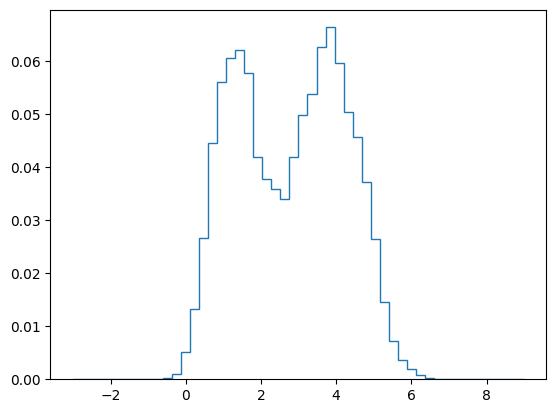

In [33]:
logits = model.forward(torch.from_numpy(data.test.sequences[0]),
                       torch.from_numpy(data.test.structures[0]),
                       torch.from_numpy(data.test.static_features[0]),
                       embeddings=embeddings_dict[data.test.row_keys[0]].to(torch.float32))

probs = torch.softmax(logits, dim=-1) # shape (batch_size, num_bins)
probs = probs.detach().numpy()

plt.stairs(probs, data.bin_edges/np.log(10))

In [24]:
probs

array([5.1968991e-06, 9.9416811e-06, 5.7173797e-06, 8.1465432e-06,
       8.5143056e-06, 7.4327145e-06, 5.5178230e-06, 9.0181666e-06,
       1.9553370e-05, 4.7446978e-05, 3.3946391e-04, 1.1236651e-03,
       5.1533943e-03, 1.3320953e-02, 2.6103724e-02, 3.6658548e-02,
       4.2934049e-02, 4.8338041e-02, 4.9107410e-02, 4.5386095e-02,
       3.4662735e-02, 3.2245006e-02, 2.8148873e-02, 2.6892778e-02,
       2.9345956e-02, 3.6188696e-02, 4.7888353e-02, 6.5504529e-02,
       7.4657500e-02, 8.5076191e-02, 7.6505348e-02, 6.5650441e-02,
       5.0588507e-02, 3.6668722e-02, 1.8812014e-02, 1.0084537e-02,
       5.8458373e-03, 3.4566252e-03, 1.6245771e-03, 8.7253243e-04,
       3.6126442e-04, 1.5806747e-04, 8.4077277e-05, 4.1903626e-05,
       1.0102642e-05, 5.3019312e-06, 6.0229399e-06, 5.2019418e-06,
       1.0017753e-05, 6.4301721e-06], dtype=float32)

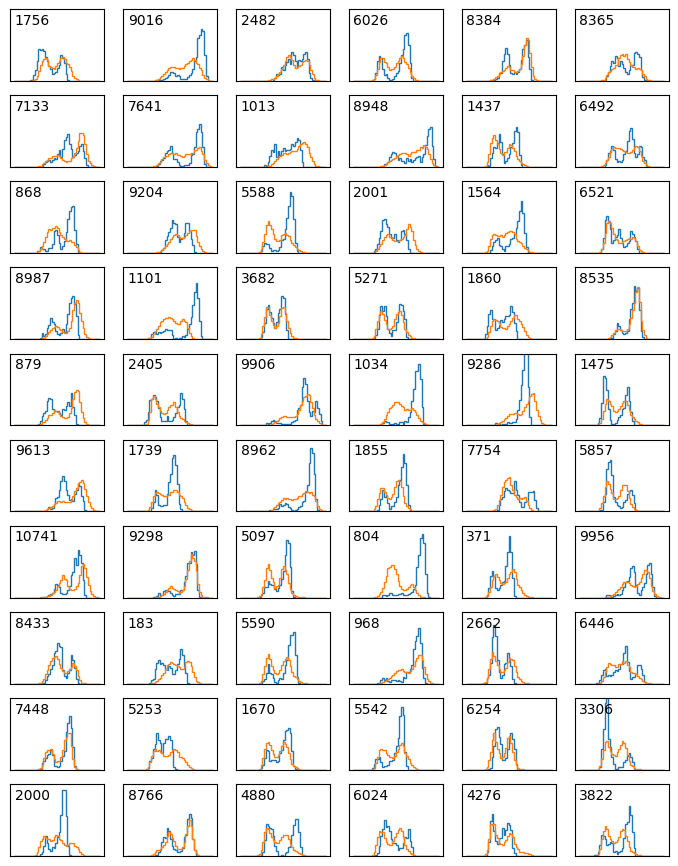

In [34]:
width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))

offset = 0
for i in range(offset, len(data.test.row_keys)+offset):
    if i-offset == n_x*n_y:
        break

    i_x = (i-offset) % n_x
    i_y = int((i-offset)/n_x)

    ax = axs[i_y][i_x]
    ax.stairs(data.test.targets[i], data.bin_edges/np.log(10))

    logits = model.forward(torch.from_numpy(data.test.sequences[i]),
                           torch.from_numpy(data.test.structures[i]),
                           torch.from_numpy(data.test.static_features[i]),
                           embeddings=embeddings_dict[data.test.row_keys[i]].to(torch.float32))

    probs = torch.softmax(logits, dim=-1) # shape (batch_size, num_bins)
    probs = probs.detach().numpy()
    ax.stairs(probs, data.bin_edges/np.log(10))

    ax.set_ylim(0,0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.05, 0.95, str(data.test.row_keys[i]), transform=ax.transAxes, verticalalignment='top')

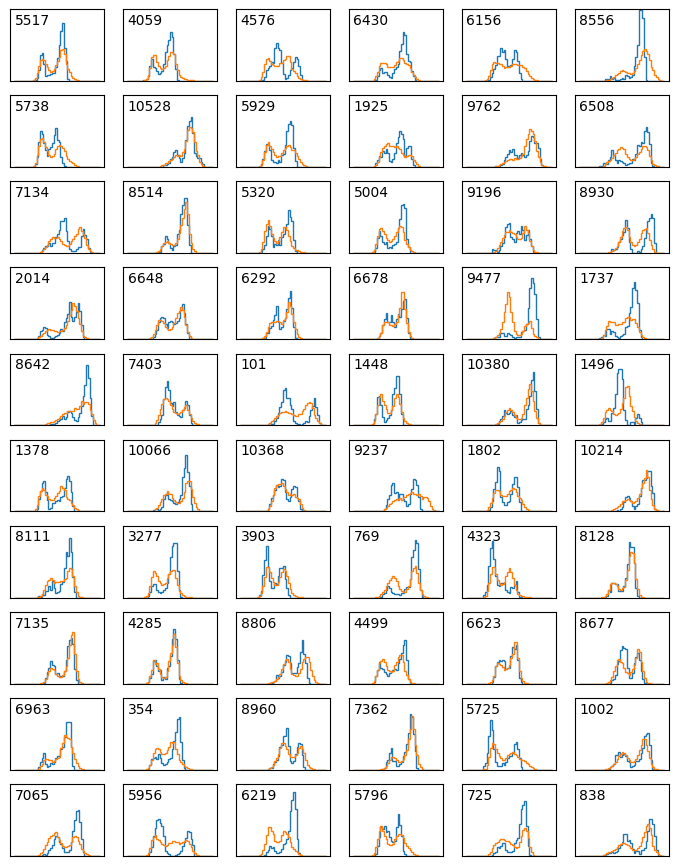

In [36]:
w = []
h = []

width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))

offset = 0
for i in range(offset, len(data.train.row_keys)+offset):
    if i-offset == n_x*n_y:
        break

    i_x = (i-offset) % n_x
    i_y = int((i-offset)/n_x)

    ax = axs[i_y][i_x]
    ax.stairs(data.train.targets[i], data.bin_edges/np.log(10))

    logits = model.forward(torch.from_numpy(data.train.sequences[i]),
                           torch.from_numpy(data.train.structures[i]),
                           torch.from_numpy(data.train.static_features[i]),
                           embeddings=embeddings_dict[data.train.row_keys[i]].to(torch.float32))
    h.append(logits.detach().numpy())

    probs = torch.softmax(logits, dim=-1) # shape (batch_size, num_bins)
    probs = probs.detach().numpy()
    w.append(probs)
    ax.stairs(probs, data.bin_edges/np.log(10))

    ax.set_ylim(0,0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.05, 0.95, str(data.train.row_keys[i]), transform=ax.transAxes, verticalalignment='top')

In [23]:
w = np.array(w)
np.std(w, axis=0)

array([2.7744605e-05, 2.8827417e-05, 3.4441386e-05, 2.7051445e-05,
       3.0266490e-05, 3.4837747e-05, 3.4145629e-05, 2.8700151e-05,
       3.3085260e-05, 6.5397209e-05, 3.4810661e-04, 1.5210167e-03,
       5.7530082e-03, 1.3251181e-02, 2.1914396e-02, 2.5502531e-02,
       2.4590874e-02, 2.1063104e-02, 1.6705750e-02, 1.2987534e-02,
       1.1712579e-02, 1.0215721e-02, 9.1311317e-03, 6.3899020e-03,
       7.0970231e-03, 9.0085594e-03, 9.8867612e-03, 9.8462235e-03,
       8.3367592e-03, 8.5023111e-03, 9.8095546e-03, 1.2343357e-02,
       1.4509642e-02, 1.7851783e-02, 2.0313576e-02, 2.1973349e-02,
       2.3175841e-02, 2.2219261e-02, 2.1826472e-02, 2.1440525e-02,
       1.7627379e-02, 1.4393041e-02, 1.1529131e-02, 8.6950893e-03,
       5.7633989e-03, 3.5214936e-03, 1.9304798e-03, 8.4867311e-04,
       2.4456703e-04, 4.4717715e-05], dtype=float32)

In [24]:
h = np.array(h)
np.std(h, axis=0)

array([0.7658184 , 0.9432733 , 1.0275857 , 0.94101006, 0.9522504 ,
       1.0027742 , 0.97999275, 0.93865955, 0.98256016, 1.1413633 ,
       1.6932342 , 2.2473853 , 2.8228278 , 2.6979146 , 2.5444422 ,
       2.1621222 , 1.6133273 , 1.1867615 , 0.8816066 , 0.6755507 ,
       0.517456  , 0.4480074 , 0.42448866, 0.40829328, 0.41645634,
       0.4708814 , 0.453216  , 0.41061038, 0.39772958, 0.3704092 ,
       0.3701638 , 0.4099722 , 0.4600981 , 0.5825173 , 0.76801634,
       0.9515788 , 1.1205188 , 1.3219671 , 1.4774292 , 1.6751359 ,
       1.7377537 , 1.8132259 , 1.7954189 , 1.879463  , 1.9579029 ,
       1.7475237 , 1.76214   , 1.5374689 , 1.1166204 , 0.5951806 ],
      dtype=float32)

In [25]:
model.BATCHING

'padded'

In [26]:
embeddings_dict = torch.load(EMBEDDING_PATH)
train_loader = make_dataloader(data.train, batching=model.BATCHING, batch_size=32, shuffle=True, embedding_dict=embeddings_dict)

In [76]:
for sequences, structures, statics, targets, embeds, lengths in train_loader:
    #print(sequences.shape)
    print(sequences.std(dim=0).mean().item(),
          structures.std(dim=0).mean().item(),
          statics.std(dim=0).mean().item())

0.22837598621845245 0.24087674915790558 0.7731809020042419
0.2735397219657898 0.280783087015152 0.83114093542099
0.2885758876800537 0.29298922419548035 1.0368391275405884
0.25122255086898804 0.25660911202430725 1.4424376487731934
0.2521970570087433 0.2674678564071655 0.9223086833953857
0.25626417994499207 0.2689751982688904 0.8341054320335388
0.3069630265235901 0.31315699219703674 0.7511350512504578
0.22843334078788757 0.23695144057273865 0.7798891663551331
0.30188727378845215 0.3043622672557831 1.0920840501785278
0.2833115756511688 0.2956066131591797 0.7848604321479797
0.2614814341068268 0.2716248631477356 0.9279477596282959
0.3037749230861664 0.3138868808746338 0.8996109962463379
0.3219386339187622 0.3318806290626526 0.7975619435310364
0.27377578616142273 0.2843784987926483 1.041507363319397
0.25556835532188416 0.2661426067352295 0.8817042708396912
0.2411659210920334 0.2514646351337433 1.2718558311462402
0.30871066451072693 0.31067803502082825 0.946960985660553
0.24063456058502197 0.

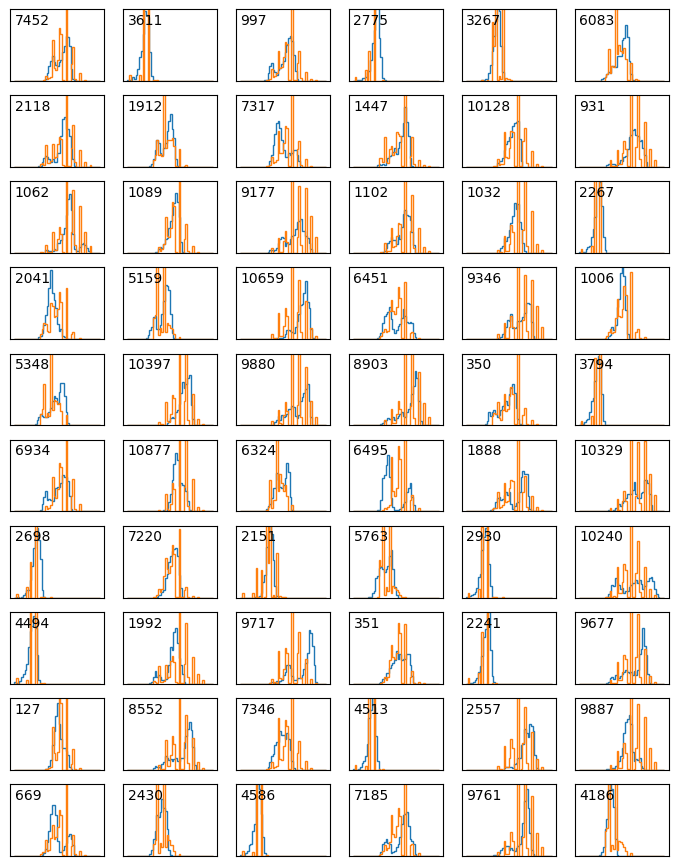

In [164]:
width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))

offset = 0
for i in range(offset, len(data.train.row_keys)+offset):
    if i-offset == n_x*n_y:
        break

    i_x = (i-offset) % n_x
    i_y = int((i-offset)/n_x)

    ax = axs[i_y][i_x]
    ax.stairs(data.train.targets[i], data.bin_edges/np.log(10))

    logits = model.forward(torch.from_numpy(data.train.sequences[i]),
                           torch.from_numpy(data.train.structures[i]),
                           torch.from_numpy(data.train.static_features[i]),
                        embeddings=None)

    weights = torch.softmax(logits, dim=-1) # shape (batch_size, num_bins)

    # xgrid = torch.outer(torch.ones(weights.shape[-1]), torch.arange(weights.shape[-1])) # shape (num_bins, num_bins)
    # means = xgrid.T # shape (num_bins, num_bins)
    # bandwidth = BANDWIDTH
    # gaussians = 1/(math.sqrt(2*math.pi)*bandwidth)*torch.exp(-0.5*((xgrid - means)/bandwidth)**2) # shape (num_bins, num_bins)
    # probs = weights @ gaussians # shape (batch_size, num_bins)
    # normalizations = torch.ones(probs.shape[-1]) # shape (batch_size, num_bins)
    # probs /= normalizations # shape (batch_size, num_bins)
    # probs = probs.detach().numpy()

    ax.stairs(weights.detach().numpy(), data.bin_edges/np.log(10))

    ax.set_ylim(0,0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.05, 0.95, str(data.train.row_keys[i]), transform=ax.transAxes, verticalalignment='top')